In [ ]:

import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge, Lasso
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, log_loss, confusion_matrix, roc_curve, auc
)

url = "https://raw.githubusercontent.com/xuzijan/Bank-Marketing-Dataset/main/bank.csv"

df = pd.read_csv(url)
print(df.head(10))

print("\nValori lipsă pe coloană:\n", df.isna().sum())

print(df.info())
print(df.describe())
print("\nDistribuție  (marital):\n", df["marital"].value_counts())
print("\nDistribuție  (housing):\n", df["housing"].value_counts())
print("\nDistribuție  (loan):\n", df["loan"].value_counts())
print("\nDistribuție etichetă (deposit):\n", df["deposit"].value_counts())

   age         job   marital  education default  balance housing loan  \
0   59      admin.   married  secondary      no     2343     yes   no   
1   56      admin.   married  secondary      no       45      no   no   
2   41  technician   married  secondary      no     1270     yes   no   
3   55    services   married  secondary      no     2476     yes   no   
4   54      admin.   married   tertiary      no      184      no   no   
5   42  management    single   tertiary      no        0     yes  yes   
6   56  management   married   tertiary      no      830     yes  yes   
7   60     retired  divorced  secondary      no      545     yes   no   
8   37  technician   married  secondary      no        1     yes   no   
9   28    services    single  secondary      no     5090     yes   no   

   contact  day month  duration  campaign  pdays  previous poutcome deposit  
0  unknown    5   may      1042         1     -1         0  unknown     yes  
1  unknown    5   may      1467         

In [ ]:
# Convertim eticheta: yes=1 (deposit), B=0 (no deposit)
df = df.copy()
df["target"] = df["deposit"].map({"yes": 1, "no": 0}).astype(int)
df["housing_nr"] = df["housing"].map({"yes": 1, "no": 0}).astype(int)
df["loan_nr"] = df["loan"].map({"yes": 1, "no": 0}).astype(int)
df["marital_nr"] = df["marital"].map({"married": 2, "single": 1, "divorced": 0}).astype(int)
print(df[["deposit", "target"]].head())

features = df.select_dtypes(include='number').drop(columns='target').columns
X = df.select_dtypes(include=['int64', 'float64']).drop(columns='target')
y = df["target"].values


  deposit  target
0     yes       1
1     yes       1
2     yes       1
3     yes       1
4     yes       1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Acuratețe (train):", accuracy_score(y_train, model.predict(X_train_scaled)))
print("Acuratețe (test): ", accuracy_score(y_test, y_pred))
print("Log Loss (test): ", log_loss(y_test, y_proba))

print("\nIntercept:", model.intercept_)
print("Coeficienți (pentru features în ordinea {}):".format(features), model.coef_)


Acuratețe (train): 0.7779146600963154
Acuratețe (test):  0.7765338110165696
Log Loss (test):  0.4802842512095803

Intercept: [-0.01903005]
Coeficienți (pentru features în ordinea Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'housing_nr', 'loan_nr', 'marital_nr'],
      dtype='object')): [[-0.01731808  0.15744576 -0.0649961   1.67283381 -0.38703455  0.31032942
   0.2864217  -0.6323659  -0.26924972 -0.10846244]]


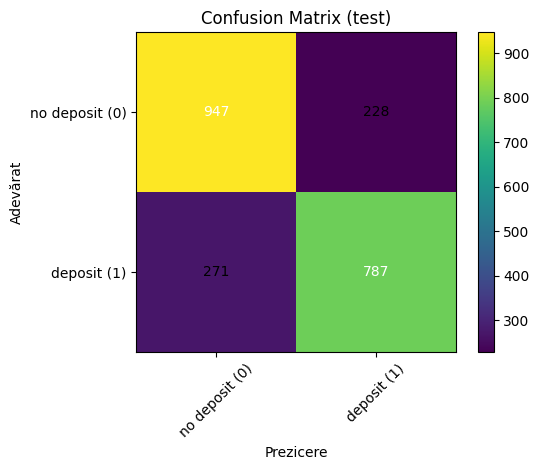

In [ ]:
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
plt.figure()
im = plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix (test)")
plt.colorbar(im, fraction=0.046, pad=0.04)
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["no deposit (0)", "deposit (1)"], rotation=45)
plt.yticks(tick_marks, ["no deposit (0)", "deposit (1)"])

# Anotări pe pătrate
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.ylabel("Adevărat")
plt.xlabel("Prezicere")
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)

n_list = [10, 50, 100, 200, 400, 800]
rows = []

for n in n_list:
    rf = RandomForestClassifier(n_estimators=n, oob_score=True, n_jobs=-1, random_state=42)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    acc = accuracy_score(y_test, pred)
    score = rf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, score)
    rows.append({'n_estimators': n, 'test_accuracy': acc, 'test_roc_auc': auc, 'oob_score': rf.oob_score_})

rf_df = pd.DataFrame(rows)


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


In [ ]:
# TODO: Alege configurarea cu cel mai mare ROC-AUC

best_idx = rf_df['test_roc_auc'].idxmax()
best_n = int(rf_df.loc[best_idx, 'n_estimators'])
rf_best = RandomForestClassifier(n_estimators=best_n, oob_score=True, n_jobs=-1, random_state=42)
rf_best.fit(X_train, y_train)

pred_b = rf_best.predict(X_test)
acc_b = accuracy_score(y_test, pred_b)
print(f"Acuratețe (RF best, n={best_n}): {acc_b:.4f}")
score_b = rf_best.predict_proba(X_test)[:, 1]
auc_b = roc_auc_score(y_test, score_b)
print(f"ROC-AUC (RF best, n={best_n}): {auc_b:.4f}")

Acuratețe (RF best, n=800): 0.8110
ROC-AUC (RF best, n=800): 0.8861


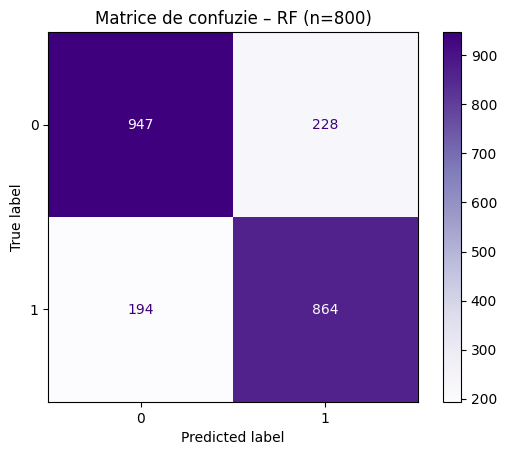

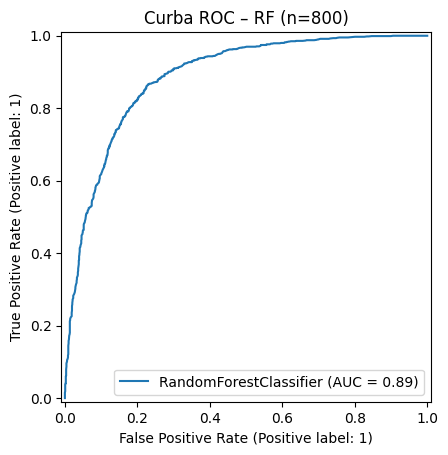

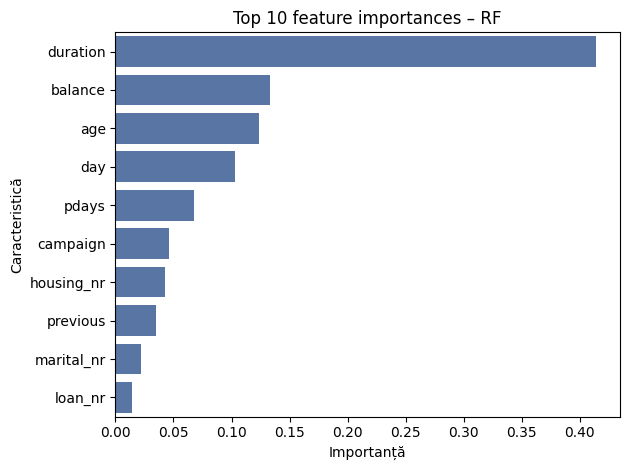

In [ ]:
# TODO: Creeza confusion matrix si feature importances
import seaborn as sns

ConfusionMatrixDisplay.from_estimator(rf_best, X_test, y_test, cmap='Purples')
plt.title(f'Matrice de confuzie – RF (n={best_n})')
plt.show()

RocCurveDisplay.from_estimator(rf_best, X_test, y_test)
plt.title(f'Curba ROC – RF (n={best_n})')
plt.show()

# Importanța caracteristicilor
importances = pd.Series(rf_best.feature_importances_, index=X_train.columns).sort_values(ascending=False)
sns.barplot(x=importances.head(10).values, y=importances.head(10).index, color='#4C72B0')
plt.title('Top 10 feature importances – RF')
plt.xlabel('Importanță'); plt.ylabel('Caracteristică'); plt.tight_layout(); plt.show()


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)

xgb_model.fit(X_train, y_train)
print("Accuracy XGBoost:", accuracy_score(y_test, xgb_model.predict(X_test)))


Accuracy XGBoost: 0.8025078369905956


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100,200,400,600],
    'learning_rate': [0.01, 0.1,0.03,0.3],
    'max_depth': [3, 4, 6, 8],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_lambda': [1, 2],
    'reg_alpha': [0, 0.1]
}

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, verbose=3)

grid_search.fit(X_train, y_train)
print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)


Streaming output truncated to the last 5000 lines.
[CV 3/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=8, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=0.8;, score=0.833 total time=   0.1s
[CV 4/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=8, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=0.8;, score=0.811 total time=   0.1s
[CV 5/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=8, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=0.8;, score=0.808 total time=   0.1s
[CV 1/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=8, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=1.0;, score=0.819 total time=   0.1s
[CV 2/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=8, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=1.0;, score=0.813 total time=   0.1s
[CV 3/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=8, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=1.0;, score=0.828 total time=   0.1s
[

In [ ]:
best_xgb = grid_search.best_estimator_

print("Test - Accuracy XGBoosting:", accuracy_score(y_test, best_xgb.predict(X_test)))
print("Train - Accuracy XGBoosting:", accuracy_score(y_train, best_xgb.predict(X_train)))

Test - Accuracy XGBoosting: 0.8137035378414689
Train - Accuracy XGBoosting: 0.8516071228581028


In [ ]:
from sklearn.metrics import roc_auc_score

# predicted probabilities for the positive class
y_proba = best_xgb.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", roc_auc)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

ROC-AUC: 0.8949660137553795
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      1175
           1       0.78      0.74      0.76      1058

    accuracy                           0.78      2233
   macro avg       0.78      0.77      0.78      2233
weighted avg       0.78      0.78      0.78      2233



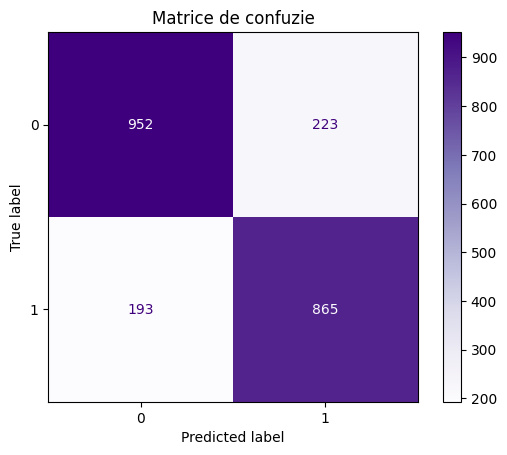

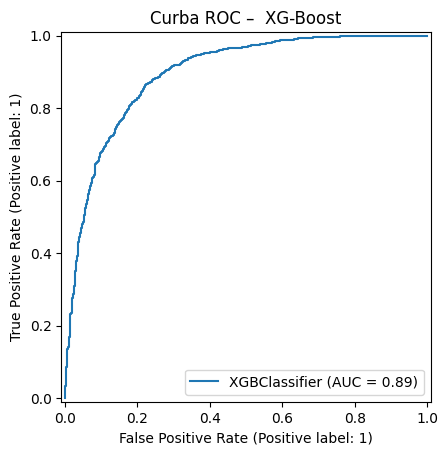

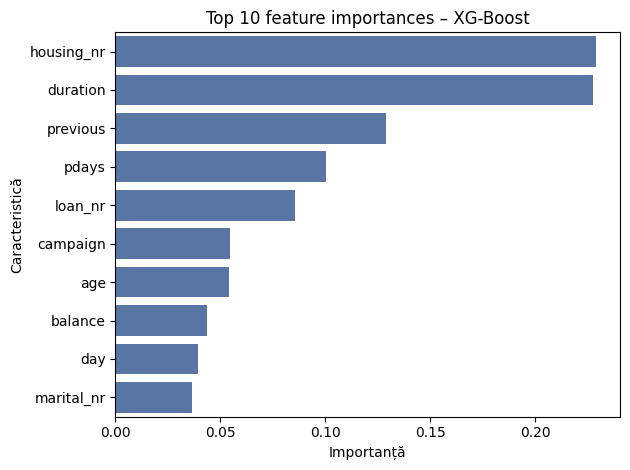

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test, cmap='Purples')
plt.title(f'Matrice de confuzie')
plt.show()

RocCurveDisplay.from_estimator(best_xgb, X_test, y_test)
plt.title(f'Curba ROC –  XG-Boost')
plt.show()


# Importanța caracteristicilor
importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
sns.barplot(x=importances.head(10).values, y=importances.head(10).index, color='#4C72B0')
plt.title('Top 10 feature importances – XG-Boost')
plt.xlabel('Importanță'); plt.ylabel('Caracteristică'); plt.tight_layout(); plt.show()
